In [ ]:
import h5py
import torch
import torch.nn.functional as F
from tqdm import tqdm
import gc

from src.utils import utils
from src.utils import plots
from src.models import models
from src.models import foundation_models as rsfm

dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(dev)
print(f"Using device: {dev}")

global_path = "/home/ids/edabier/HSU"
file_path = f"{global_path}/SS-HSU_benchmark/datasets/PRS_L2D_STD_20220812100446_20220812100450_0001.he5"

with h5py.File(file_path, 'r') as f:
    # Exemple : chemin vers les données de réflectance
    data_path = '/HDFEOS/SWATHS/PRS_L2D_HCO/Data Fields/SWIR_Cube'
    if data_path in f:
        SWIR_data = f[data_path][:]
        print(f"Forme des données SWIR : {SWIR_data.shape}")
        
    data_path = '/HDFEOS/SWATHS/PRS_L2D_HCO/Data Fields/VNIR_Cube'
    if data_path in f:
        VNIR_data = f[data_path][:]
        print(f"Forme des données VNIR : {VNIR_data.shape}")
Y_swir = torch.tensor(SWIR_data, dtype=torch.float).permute(1,0,2)
Y_vnir = torch.tensor(VNIR_data, dtype=torch.float).permute(1,0,2)
B_init, H_init, W_init = Y_swir.shape

Using device: cuda:0
Forme des données SWIR : (1243, 173, 1226)
Forme des données VNIR : (1243, 66, 1226)


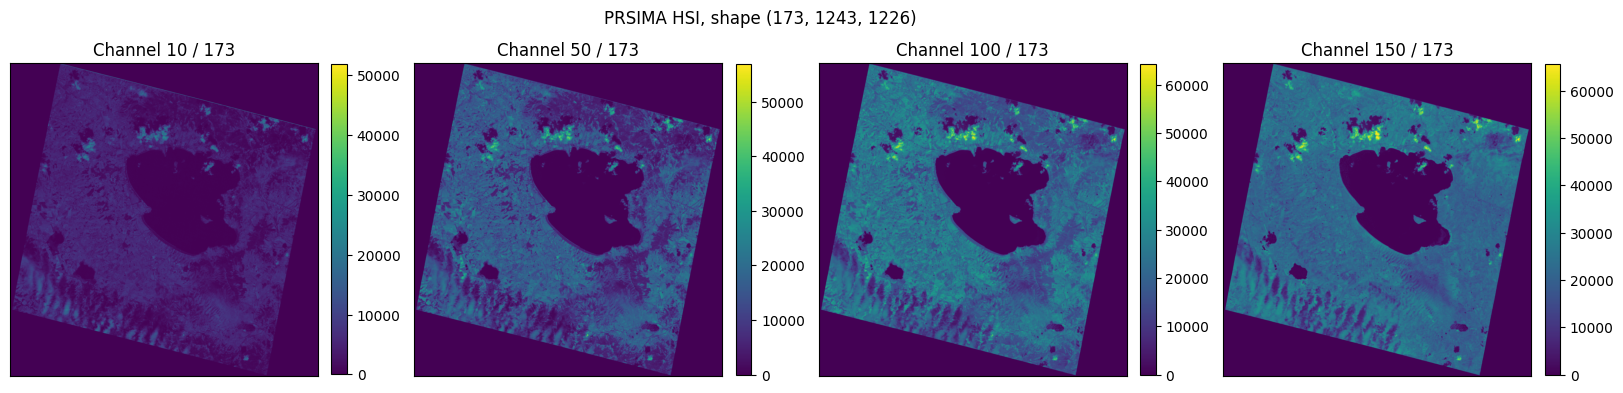

In [10]:
plots.plot_hsi(Y_swir, channels=[10,50,100,150], title=f"PRSIMA HSI, shape {B_init, H_init, W_init}")

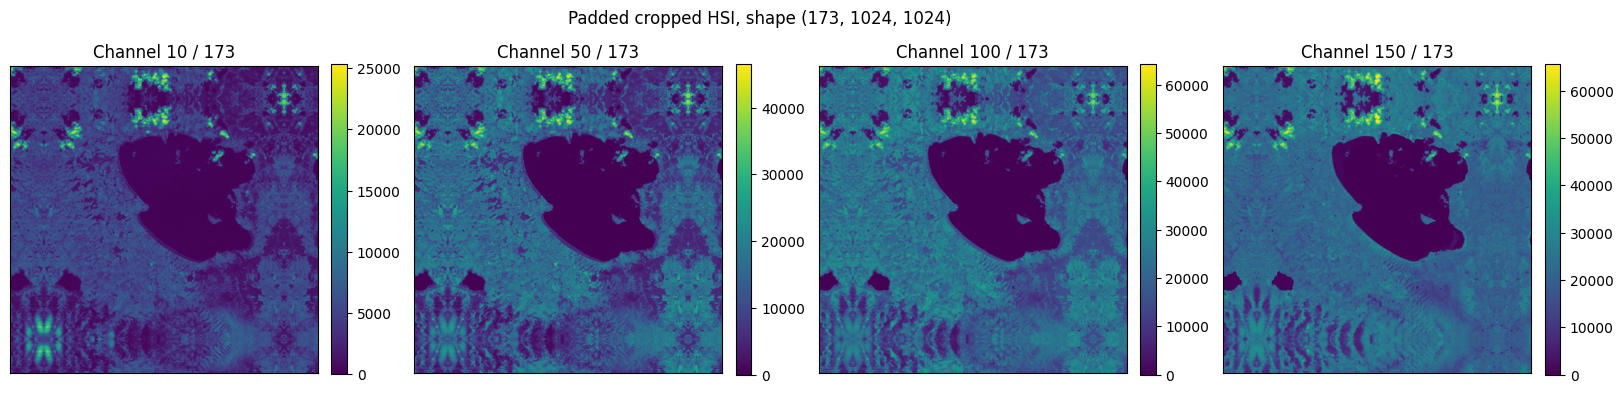

In [12]:
def center_crop(tensor, crop_size):
    """
    Args:
        tensor: Input tensor of shape (C, H, W)
        crop_size: Side length of the square crop (must be <= min(H, W))
    Returns:
        Cropped tensor of shape (C, crop_size, crop_size)
    """
    B, H, W = tensor.shape
    assert crop_size <= min(H, W), "Crop size must be <= min(H, W)"

    # Calculate starting and ending indices for height and width
    start_h = (H - crop_size) // 2
    end_h = start_h + crop_size
    start_w = (W - crop_size) // 2
    end_w = start_w + crop_size

    # Crop the tensor
    cropped_tensor = tensor[:, start_h:end_h, start_w:end_w]

    return cropped_tensor

crop_size = 800
Y_crop = center_crop(Y_swir, crop_size)
padding = int((1024-crop_size)/2)
Y_crop = F.pad(Y_crop, pad=(padding, padding, padding, padding), mode="reflect")
B, H, W = Y_crop.shape
plots.plot_hsi(Y_crop, channels=[10,50,100,150], title=f"Padded cropped HSI, shape {B, H, W}")

feature shape: (256, 32, 32)


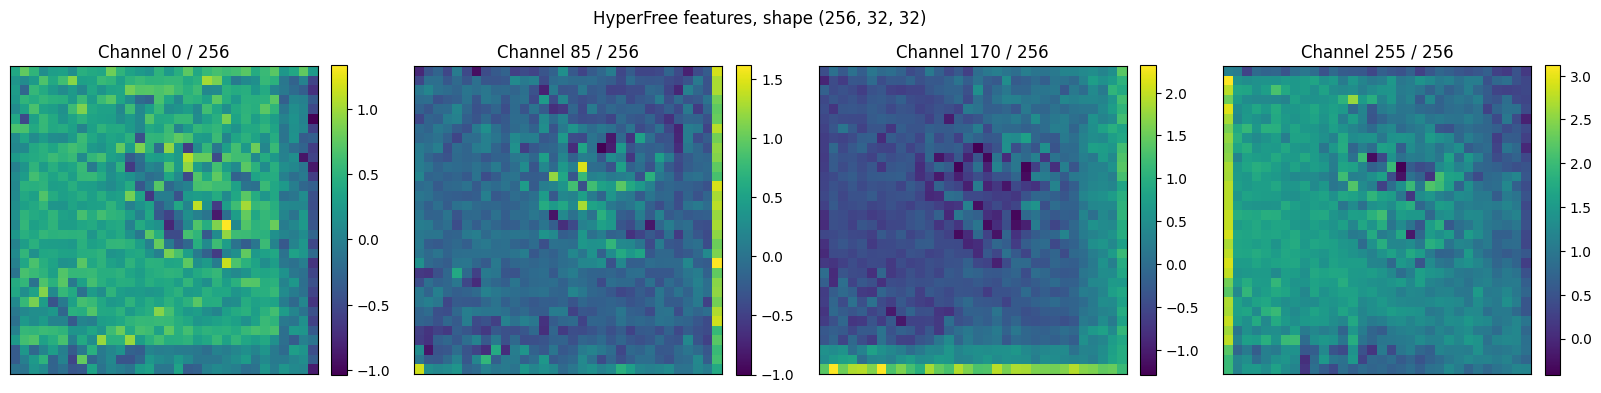

In [14]:
dataset = "prisma_swir"
wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt"
with open(wavelengths_path, "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]

fm_name = "HyperFree"
fm, Y_init_fm, new_H = rsfm.create_fm(fm_name, Y_crop.unsqueeze(0), n_features=1, size="base", version="v1", use_cls=False, extend_cls=False, path=global_path+"/benchmark", patch_size=16)
if fm_name == "DOFA":
    features = rsfm.get_dofa_features(fm, Y_init_fm, wavelengths)
elif fm_name == "HyperFree":
    features = rsfm.get_hyperfree_features(fm, Y_init_fm, wavelengths)

features = utils.oneD_to_2d(features)

# features = features[:, 8:-8, 8:-8]

D = int(features.shape[0])
alpha = int(features.shape[1])

print(f"feature shape: {D, alpha, alpha}")

title = f"H = {new_H}, "
title += r"$\alpha$"
title += f" = {alpha}"
plots.plot_hsi(features.reshape(D, alpha, alpha), 4, title=f"HyperFree features, shape {D, alpha, alpha}")

100%|██████████| 64/64 [18:46<00:00, 17.60s/it]


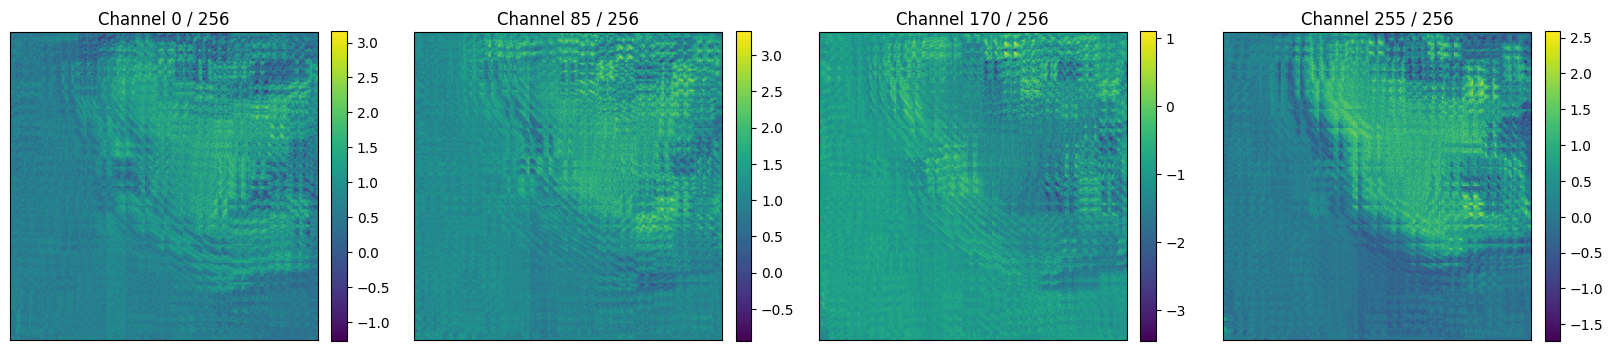

In [22]:
patch = new_H//alpha
padding = patch//2
shift = 1
x_new = torch.linspace(0, new_H - 1, new_H)
grid_y, grid_x = torch.meshgrid(x_new, x_new, indexing='ij')
grid = torch.stack((grid_x, grid_y), dim=-1).unsqueeze(0)
grid = grid / torch.tensor([(new_H - 1) / 2, (new_H - 1) / 2]) - 1

epochs, lr = 200, 0.002
optim_wrapper = dict(
    optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
    constructor='LayerDecayOptimizerConstructor_ViT',
    paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9))

Y_padded = F.pad(Y_init_fm, pad=(padding, padding, padding, padding), mode="reflect")
feature_map = torch.zeros(1, D, new_H, new_H, device=dev)

with torch.no_grad():
    for i in tqdm(range(0, 2*padding)):
        for j in range(0, 2*padding):

            n_crop = patch*(i//shift) + j//shift
            
            Y_crop = Y_padded[:, :, i:i+new_H, j:j+new_H]
            Y_crop = Y_crop.to(dev)
            _, features = rsfm.extract_f(fm, Y_crop, new_H, wavelengths, use_cls=False)

            features = utils.oneD_to_2d(features)

            features = features[:, 8:-8, 8:-8]

            feature_map[:,:, i::patch, j::patch] = features
            
            del features, Y_crop
            torch.cuda.synchronize()
            torch.cuda.empty_cache()
            gc.collect()
plots.plot_hsi(feature_map, 4)